# Aula  - Pratica semanal

**Curso: Mineração de Dados e Ciência de Dados**

**Aluno: Gisele Fonseca**

**Data: 17 de outubro**

**Descrição do Dataset**

https://archive.ics.uci.edu/dataset/186/wine+quality

**Descrição do Exercício**

Carregar o conjunto de dados em uma tabela.

Criar um gráfico de dispersão entre duas variáveis.

Gerar histogramas de quatro variáveis com diferentes números de divisões (10 e 40).

Calcular medidas estatísticas descritivas (média, mediana, moda e quartis) para todas as variáveis.

In [ ]:
# Instalar e importar bibliotecas
!pip install ucimlrepo --quiet
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from scipy import stats

In [ ]:
# Carregar o dataset Wine Quality (id=186)
wine_quality = fetch_ucirepo(id=186)

# Dados
X = wine_quality.data.features
y = wine_quality.data.targets

# Unir X e y em um único DataFrame
df = pd.concat([X, y], axis=1)

# Mostrar as primeiras linhas
df.head()


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


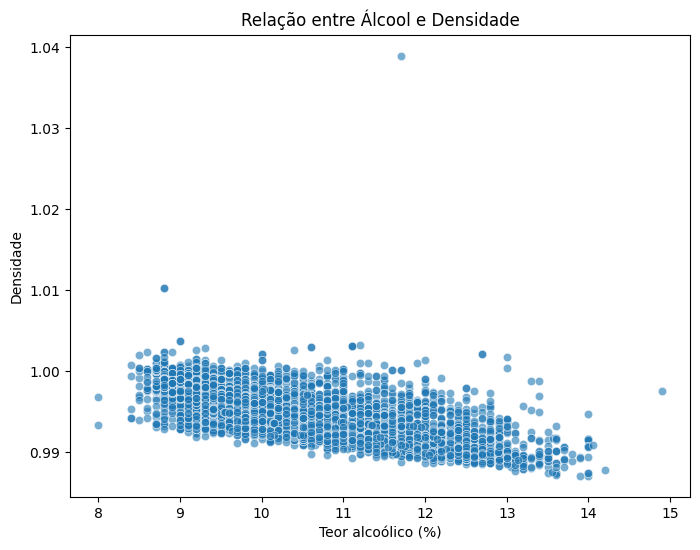

In [ ]:
# Gráfico de pontos (scatterplot)
# Exemplo: "alcohol" vs "density"
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='alcohol', y='density', alpha=0.6)
plt.title('Relação entre Álcool e Densidade')
plt.xlabel('Teor alcoólico (%)')
plt.ylabel('Densidade')
plt.show()

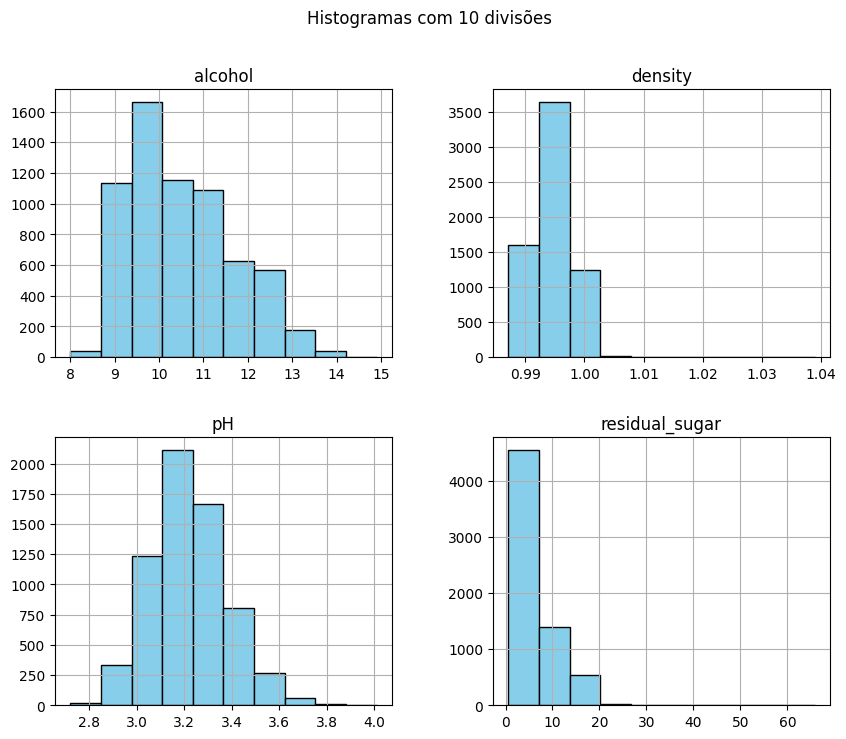

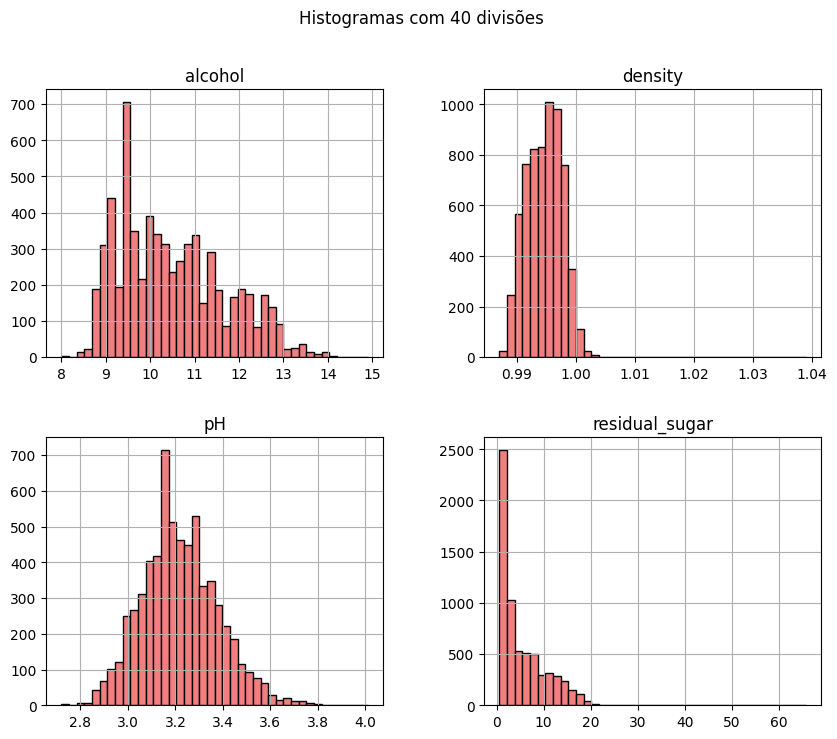

In [ ]:
# Histogramas de 4 variáveis
variaveis = ['alcohol', 'density', 'pH', 'residual_sugar']

# 10 divisões
df[variaveis].hist(bins=10, figsize=(10,8), color='skyblue', edgecolor='black')
plt.suptitle('Histogramas com 10 divisões')
plt.show()

# 40 divisões
df[variaveis].hist(bins=40, figsize=(10,8), color='lightcoral', edgecolor='black')
plt.suptitle('Histogramas com 40 divisões')
plt.show()

In [ ]:
# Cálculo de estatísticas descritivas
medias = df.mean()
medianas = df.median()
modas = df.mode().iloc[0]
quartis = df.quantile([0.25, 0.5, 0.75])

print(" MÉDIAS")
print(medias)
print("\n MEDIANAS")
print(medianas)
print("\n MODAS")
print(modas)
print("\n  QUARTIS")
print(quartis)

 MÉDIAS
fixed_acidity             7.215307
volatile_acidity          0.339666
citric_acid               0.318633
residual_sugar            5.443235
chlorides                 0.056034
free_sulfur_dioxide      30.525319
total_sulfur_dioxide    115.744574
density                   0.994697
pH                        3.218501
sulphates                 0.531268
alcohol                  10.491801
quality                   5.818378
dtype: float64

 MEDIANAS
fixed_acidity             7.00000
volatile_acidity          0.29000
citric_acid               0.31000
residual_sugar            3.00000
chlorides                 0.04700
free_sulfur_dioxide      29.00000
total_sulfur_dioxide    118.00000
density                   0.99489
pH                        3.21000
sulphates                 0.51000
alcohol                  10.30000
quality                   6.00000
dtype: float64

 MODAS
fixed_acidity             6.8000
volatile_acidity          0.2800
citric_acid               0.3000
residual_sugar  

In [ ]:
# Tabela resumo
resumo = pd.DataFrame({
    'Média': medias,
    'Mediana': medianas,
    'Moda': modas
})
resumo = pd.concat([resumo, quartis.T.rename(columns={0.25:'Q1',0.5:'Q2',0.75:'Q3'})], axis=1)
resumo

,Média,Mediana,Moda,Q1,Q2,Q3
fixed_acidity,7.215307,7.00000,6.8000,6.40000,7.00000,7.70000
volatile_acidity,0.339666,0.29000,0.2800,0.23000,0.29000,0.40000
citric_acid,0.318633,0.31000,0.3000,0.25000,0.31000,0.39000
residual_sugar,5.443235,3.00000,2.0000,1.80000,3.00000,8.10000
chlorides,0.056034,0.04700,0.0440,0.03800,0.04700,0.06500
free_sulfur_dioxide,30.525319,29.00000,29.0000,17.00000,29.00000,41.00000
total_sulfur_dioxide,115.744574,118.00000,111.0000,77.00000,118.00000,156.00000
density,0.994697,0.99489,0.9972,0.99234,0.99489,0.99699
pH,3.218501,3.21000,3.1600,3.11000,3.21000,3.32000
sulphates,0.531268,0.51000,0.5000,0.43000,0.51000,0.60000
